In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# The Heavy Weights
import tensorflow as tf
from tensorflow.keras import layers, models

# Verify we are ready to roll
print(f"TensorFlow Version: {tf.__version__}")
print("Deep Learning Environment Ready.")

TensorFlow Version: 2.20.0
Deep Learning Environment Ready.


In [2]:
data_dir = '../dataset/archive/2nd_test/2nd_test'
filenames = os.listdir(data_dir)
filenames.sort()

# Define our buckets
healthy_files = filenames[0:400]   # First 400 are Healthy
faulty_files = filenames[-100:]    # Last 100 are Faulty
all_files = healthy_files + faulty_files

# Lists to hold the raw signals
X = [] # The vibration waves
y = [] # The labels (0 or 1)

print(f"Loading {len(all_files)} files... This might take 10 seconds.")

for file in all_files:
    # 1. Load the raw file
    path = os.path.join(data_dir, file)
    df = pd.read_csv(path, sep='\t', header=None)
    
    # 2. Downsample: Take every 10th point to reduce size
    # (Original: 20,480 -> New: 2,048 points)
    signal = df.iloc[::10].values 
    
    # 3. Add to our list
    X.append(signal)
    
    # 4. Create Label
    if file in healthy_files:
        y.append(0) # Healthy
    else:
        y.append(1) # Faulty

# Convert lists to NumPy Arrays (The format TensorFlow needs)
X = np.array(X)
y = np.array(y)

print("--- Data Loaded ---")
print(f"Input Shape: {X.shape}") 
# You should see something like (500, 2048, 4)
# (500 files, 2048 time steps per file, 4 sensors)

Loading 500 files... This might take 10 seconds.
--- Data Loaded ---
Input Shape: (500, 2048, 4)


In [3]:
# 1. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

Training Data Shape: (400, 2048, 4)
Test Data Shape: (100, 2048, 4)


In [4]:
# 1. Initialize the Neural Network
model = models.Sequential()

# --- THE FIX IS HERE ---
# Instead of putting input_shape inside Conv1D, we add an Input layer first.
model.add(layers.Input(shape=(2048, 4)))

# 2. First Convolutional Block
model.add(layers.Conv1D(filters=32, kernel_size=5, activation='relu'))
model.add(layers.MaxPooling1D(pool_size=2))

# 3. Second Convolutional Block
model.add(layers.Conv1D(filters=64, kernel_size=5, activation='relu'))
model.add(layers.MaxPooling1D(pool_size=2))

# 4. Flattening
model.add(layers.Flatten())

# 5. The "Brain" (Dense Layers)
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# 6. Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 2044, 32)            │             672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 1022, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 1018, 64)            │          10,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 509, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32576)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,084,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,095,969 (8.00 MB)

 Trainable params: 2,095,969 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
print("Starting Training...")

# Train for 10 "Epochs" (Go through the entire dataset 10 times)
history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_test, y_test), 
                    batch_size=32)

print("--- Training Complete ---")

Starting Training...
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.6458 - loss: 0.6819 - val_accuracy: 0.7600 - val_loss: 0.6355
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.8139 - loss: 0.4994 - val_accuracy: 0.7600 - val_loss: 0.3967
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.8093 - loss: 0.2992 - val_accuracy: 0.7600 - val_loss: 0.2912
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.8201 - loss: 0.2002 - val_accuracy: 0.7600 - val_loss: 0.2055
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.8145 - loss: 0.1912 - val_accuracy: 0.9500 - val_loss: 0.1857
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9801 - loss: 0.1524 - val_accuracy: 0.9700 - val_loss: 0.1784
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.9911 - loss: 0.1319 - val_accuracy: 0.9600 - val_loss: 0.1850
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.9915 - loss: 0.1483 

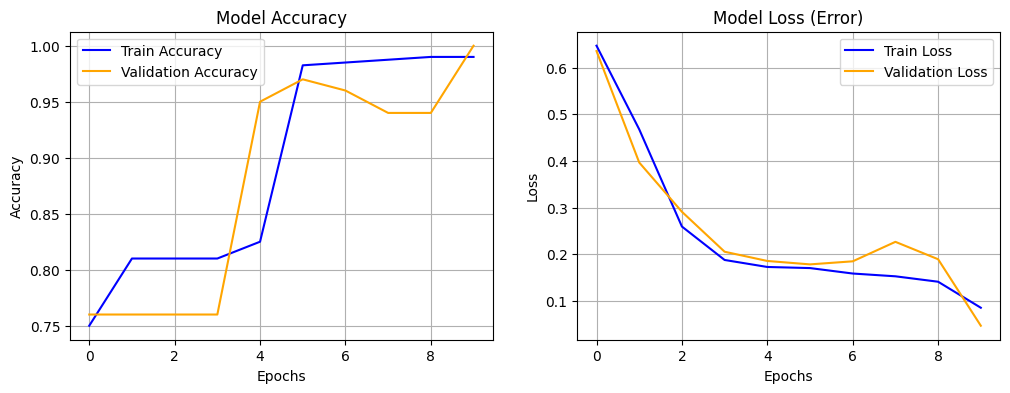

In [6]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss (The error rate)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss (Error)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [7]:
# Save the entire model (architecture + weights)
model_filename = '../models/bearing_cnn_model.keras'
model.save(model_filename)

print(f"Deep Learning Model saved to: {model_filename}")

Deep Learning Model saved to: ../models/bearing_cnn_model.keras
